<a href="https://colab.research.google.com/github/ranafikriyeak/MSc-Research/blob/main/Case_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install uv
!pip install optuna
!uv pip install --system -r /content/drive/MyDrive/code/requirements-gpu.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 25.2 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
  × No solution found when resolving dependencies:
  ╰─▶ Because ml-dtypes==0.5.4 depends on numpy>=2.1.0 and you require
      ml-dtypes==0.5.4, we can conclude that you require numpy>=2.1.0.
      And because you require numpy>=2.0,<2.1, we can conclude that your
      requirements are unsatisfiable.


In [ ]:
!pip install --upgrade jax jaxlib equinox diffrax optax optimistix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.0/403.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.8.2
    Uninstalling jaxlib-0.8.2:
      Successfully uninstalled jaxlib-0.8.2
  Attempting uninstall: jax
    Found existing installation: jax 0.8.2
    Uninstalling jax-0.8.2:
      Successfully uninstalled jax-0.8.2
  Attempting uninstall: optax
    Found existing installation: optax 0.2.4
    Uninstalling optax-0.2.4:
      Successfully uninstalled optax-0.2.4
  Attempting uninstall: equinox
    Found existing installation: equinox 0.13.2
   

JAX backend: gpu
Generating datasets for all 4 conditions...
  0noise_sameIC: noise=0%, IC spread=0%
  2noise_sameIC: noise=2%, IC spread=0%
  2noise_diffIC: noise=2%, IC spread=40%
  0noise_diffIC: noise=0%, IC spread=40%
12 model icin kullanilacak mimari: width=256, depth=4, lr=1.00e-04

CONDITION: 0noise_sameIC
  [0noise_sameIC / Baseline] checkpoint bulundu, atlaniyor.
  [0noise_sameIC / PtI] checkpoint bulundu, atlaniyor.
  [0noise_sameIC / ItP] checkpoint bulundu, atlaniyor.

CONDITION: 2noise_sameIC
  [2noise_sameIC / Baseline] checkpoint bulundu, atlaniyor.
  [2noise_sameIC / PtI] checkpoint bulundu, atlaniyor.
  [2noise_sameIC / ItP] checkpoint bulundu, atlaniyor.

CONDITION: 2noise_diffIC
  [2noise_diffIC / Baseline] checkpoint bulundu, atlaniyor.
  [2noise_diffIC / PtI] checkpoint bulundu, atlaniyor.
  [2noise_diffIC / ItP] checkpoint bulundu, atlaniyor.

CONDITION: 0noise_diffIC
  [0noise_diffIC / Baseline] checkpoint bulundu, atlaniyor.

--- Training: 0noise_diffIC / PtI -

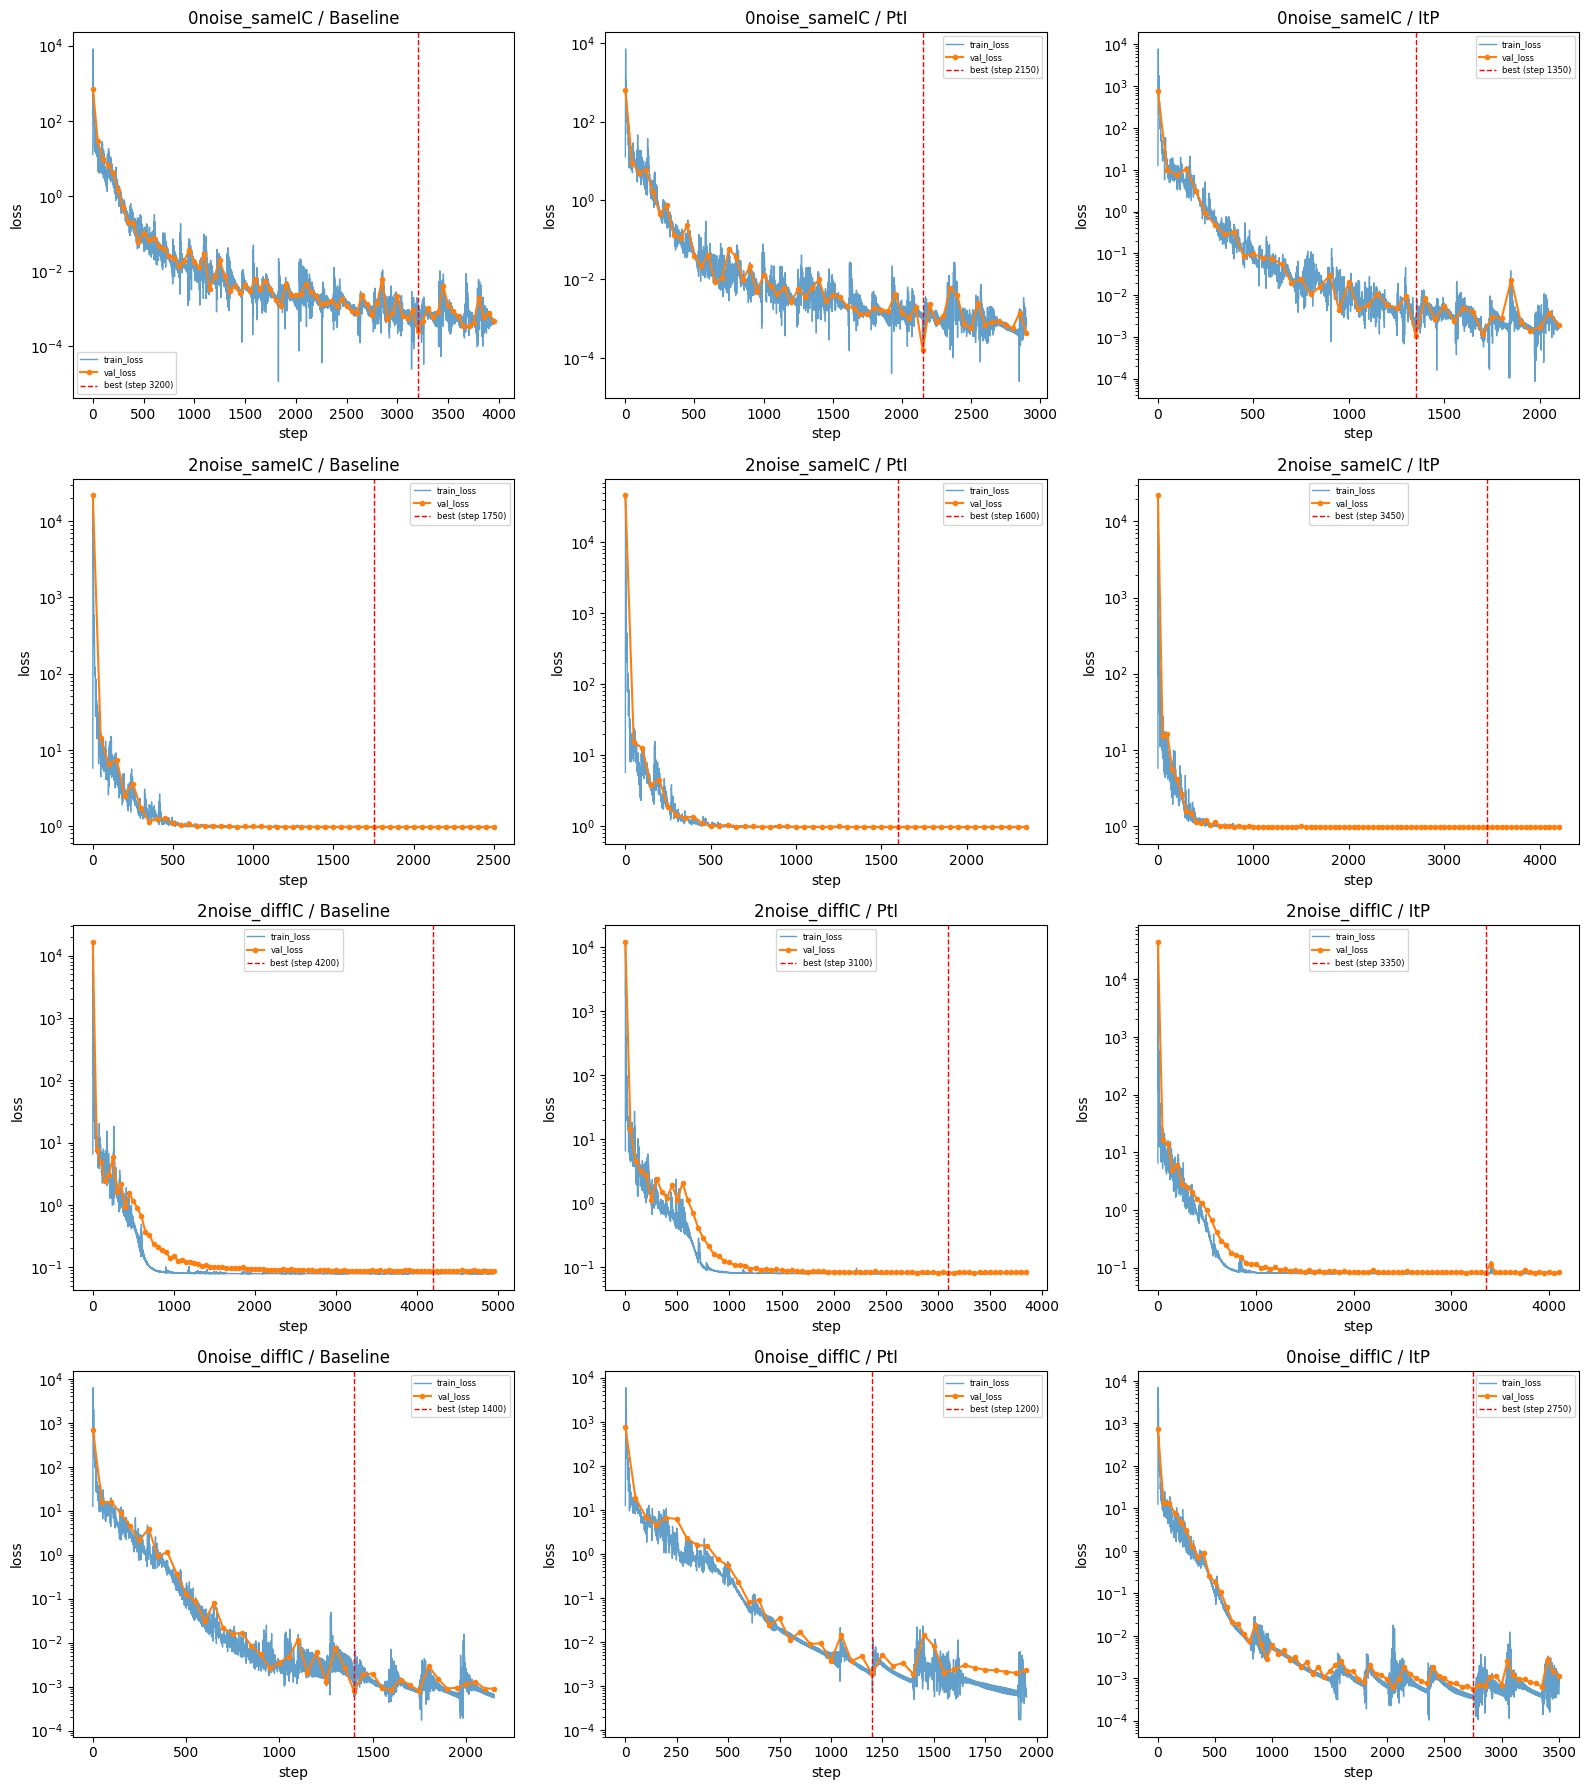

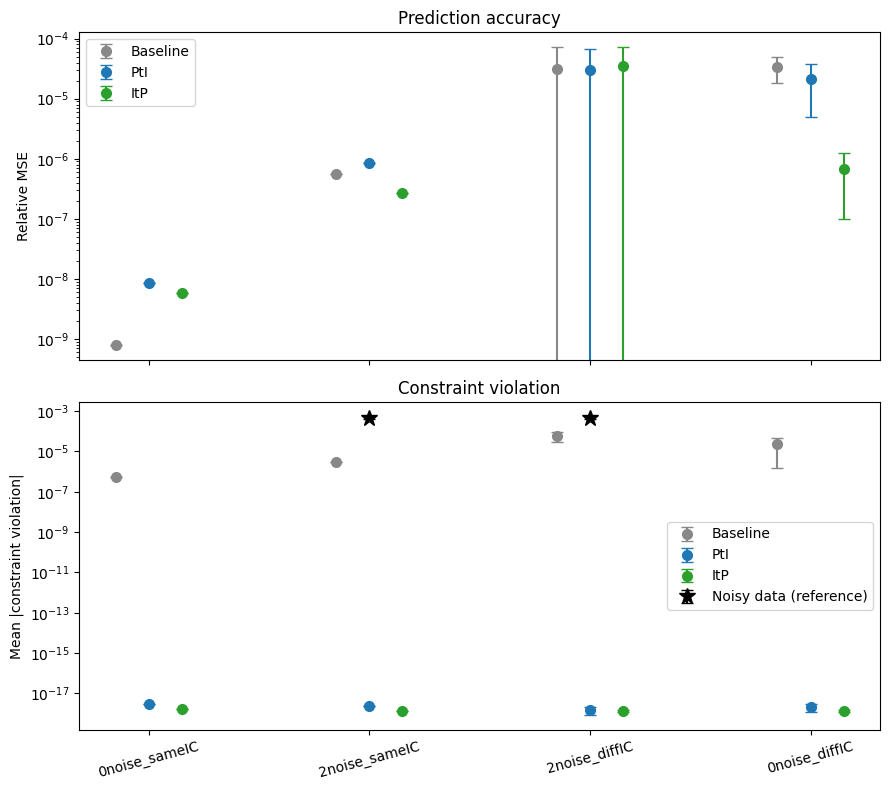

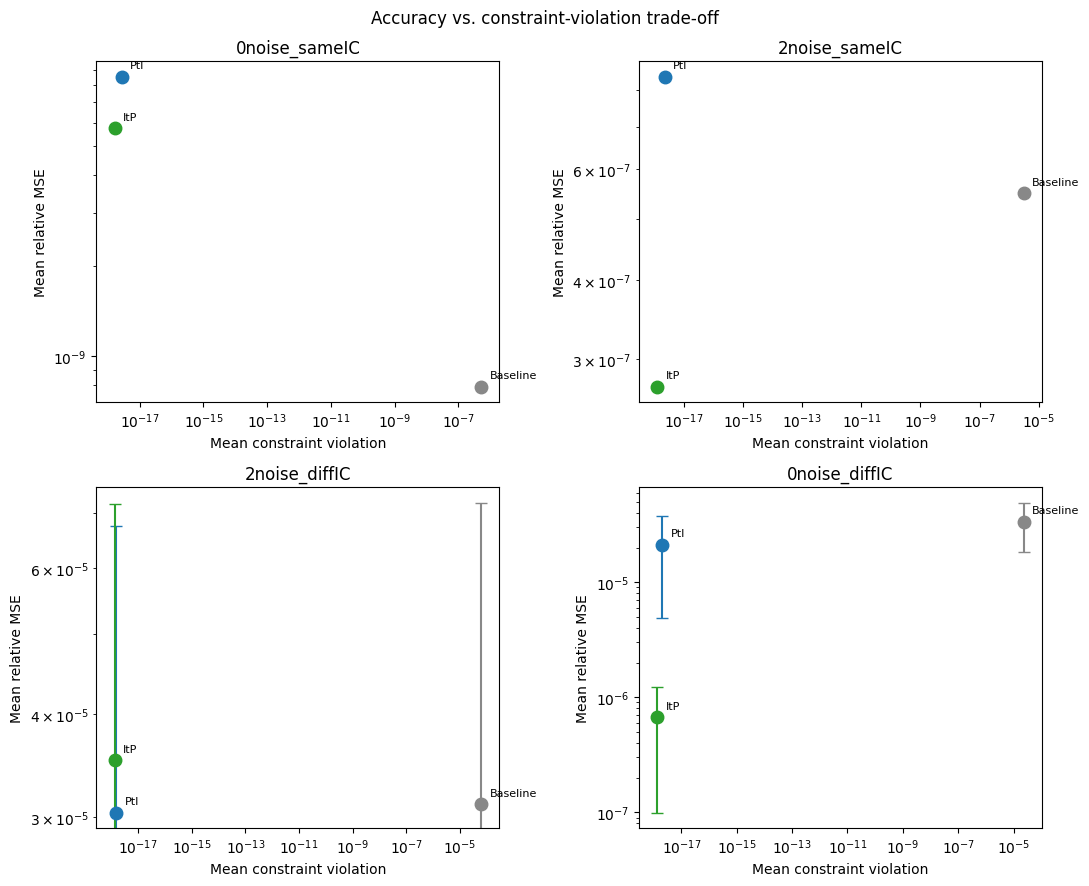

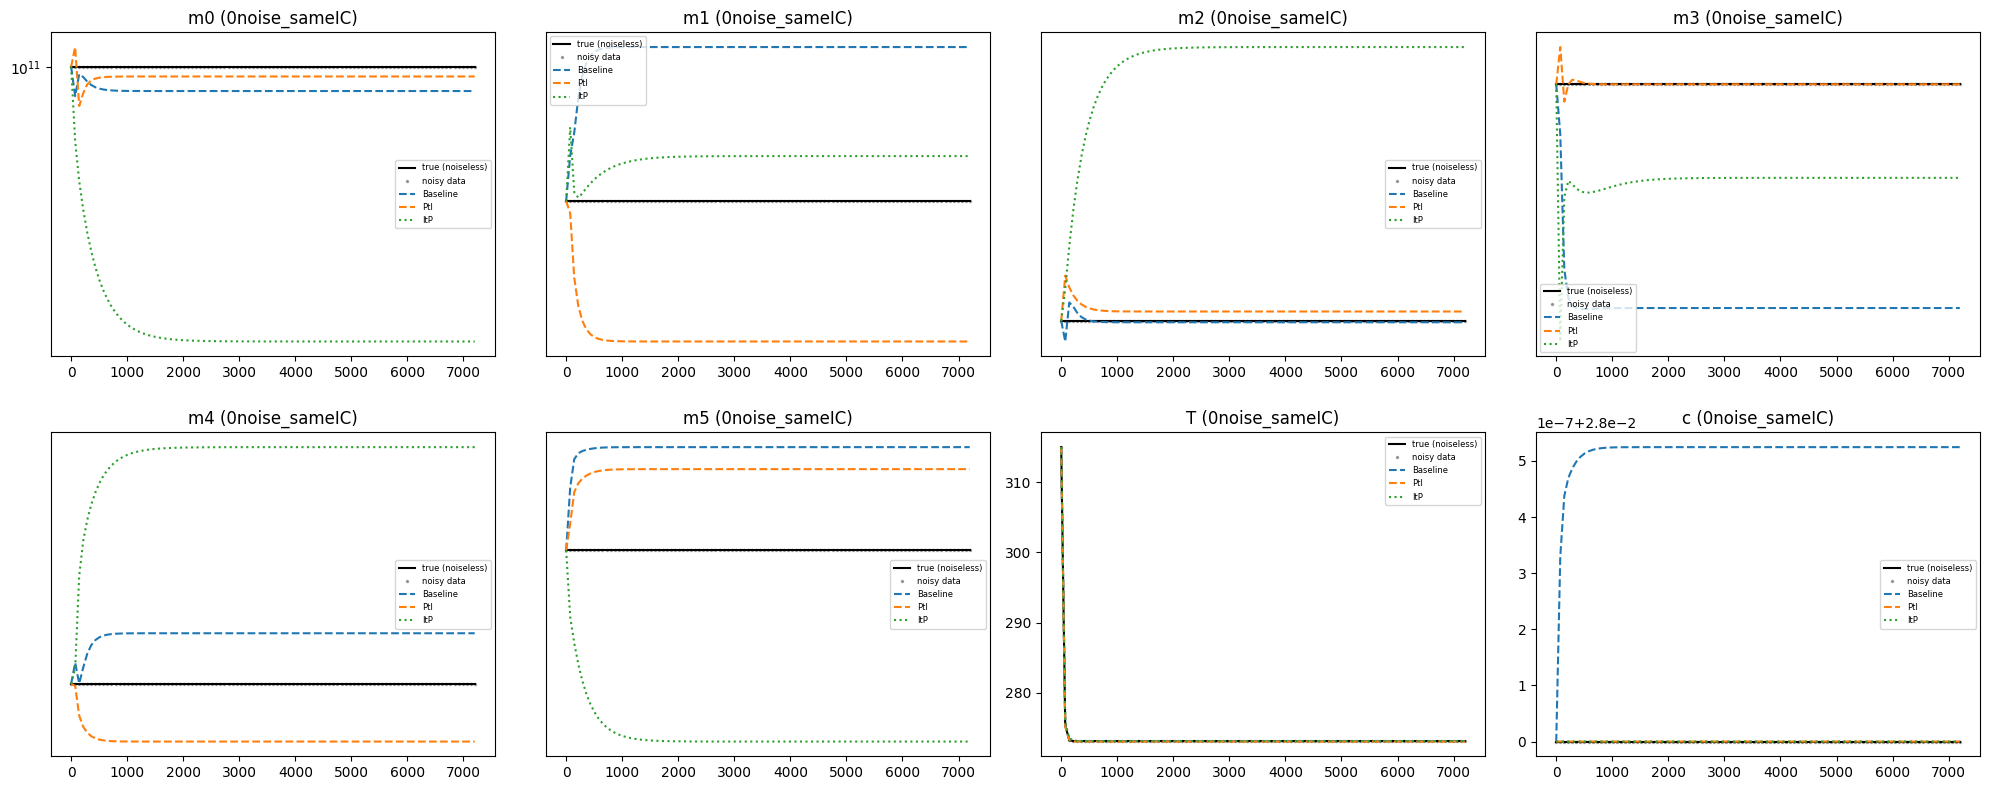

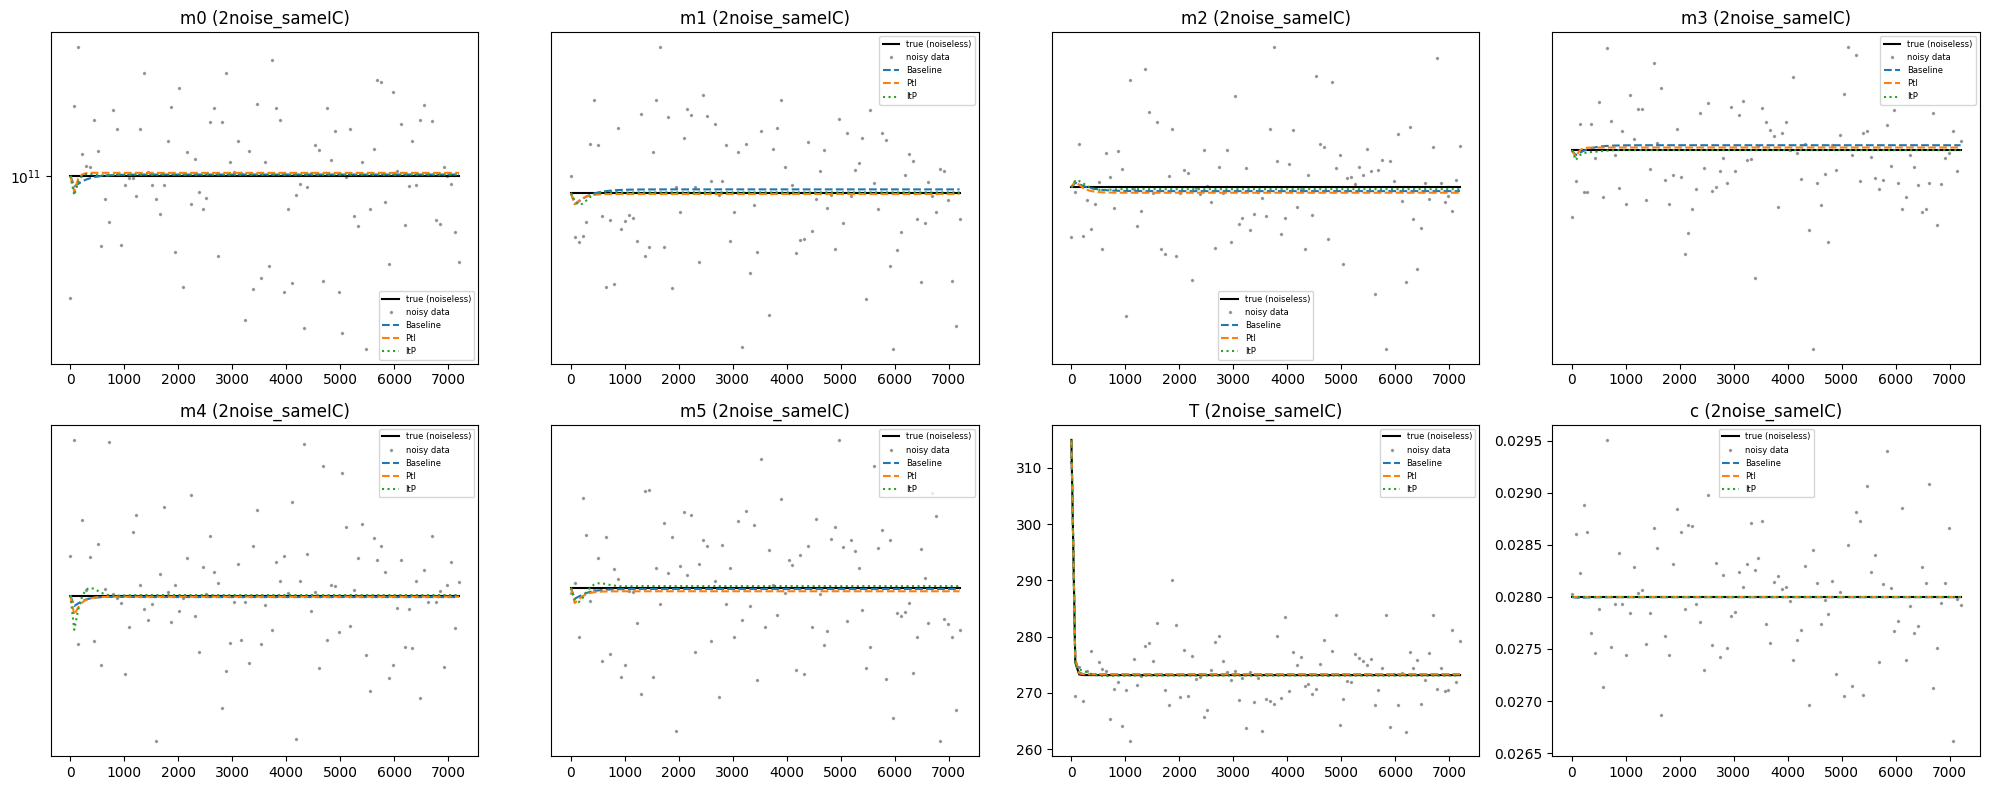

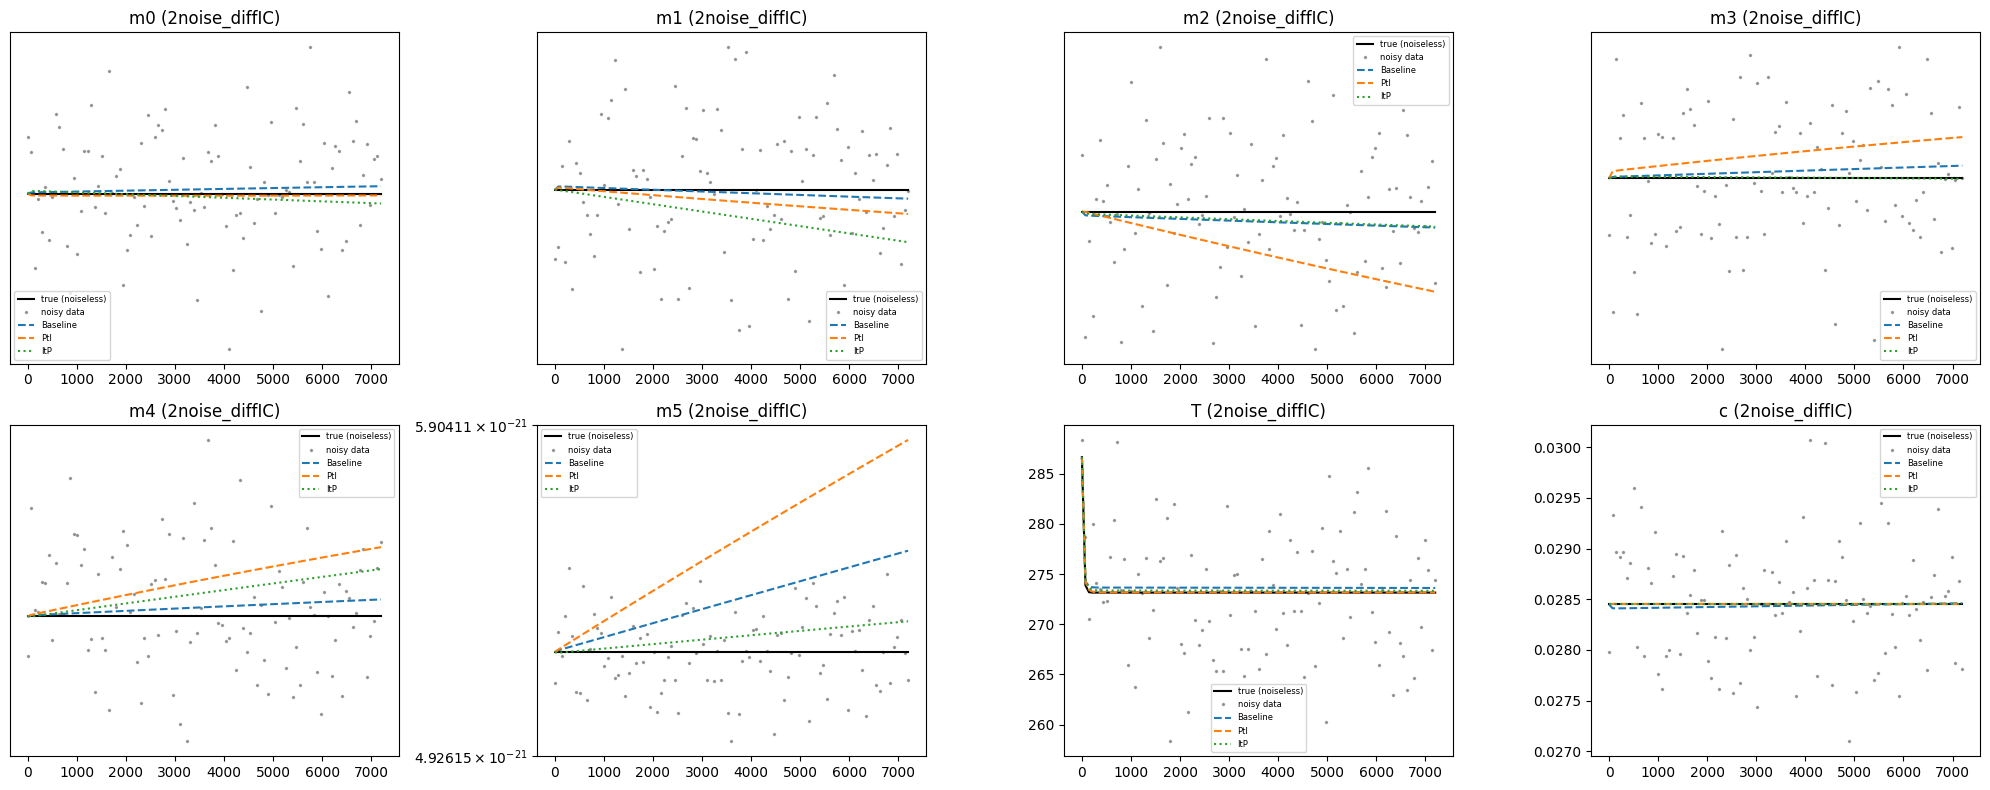

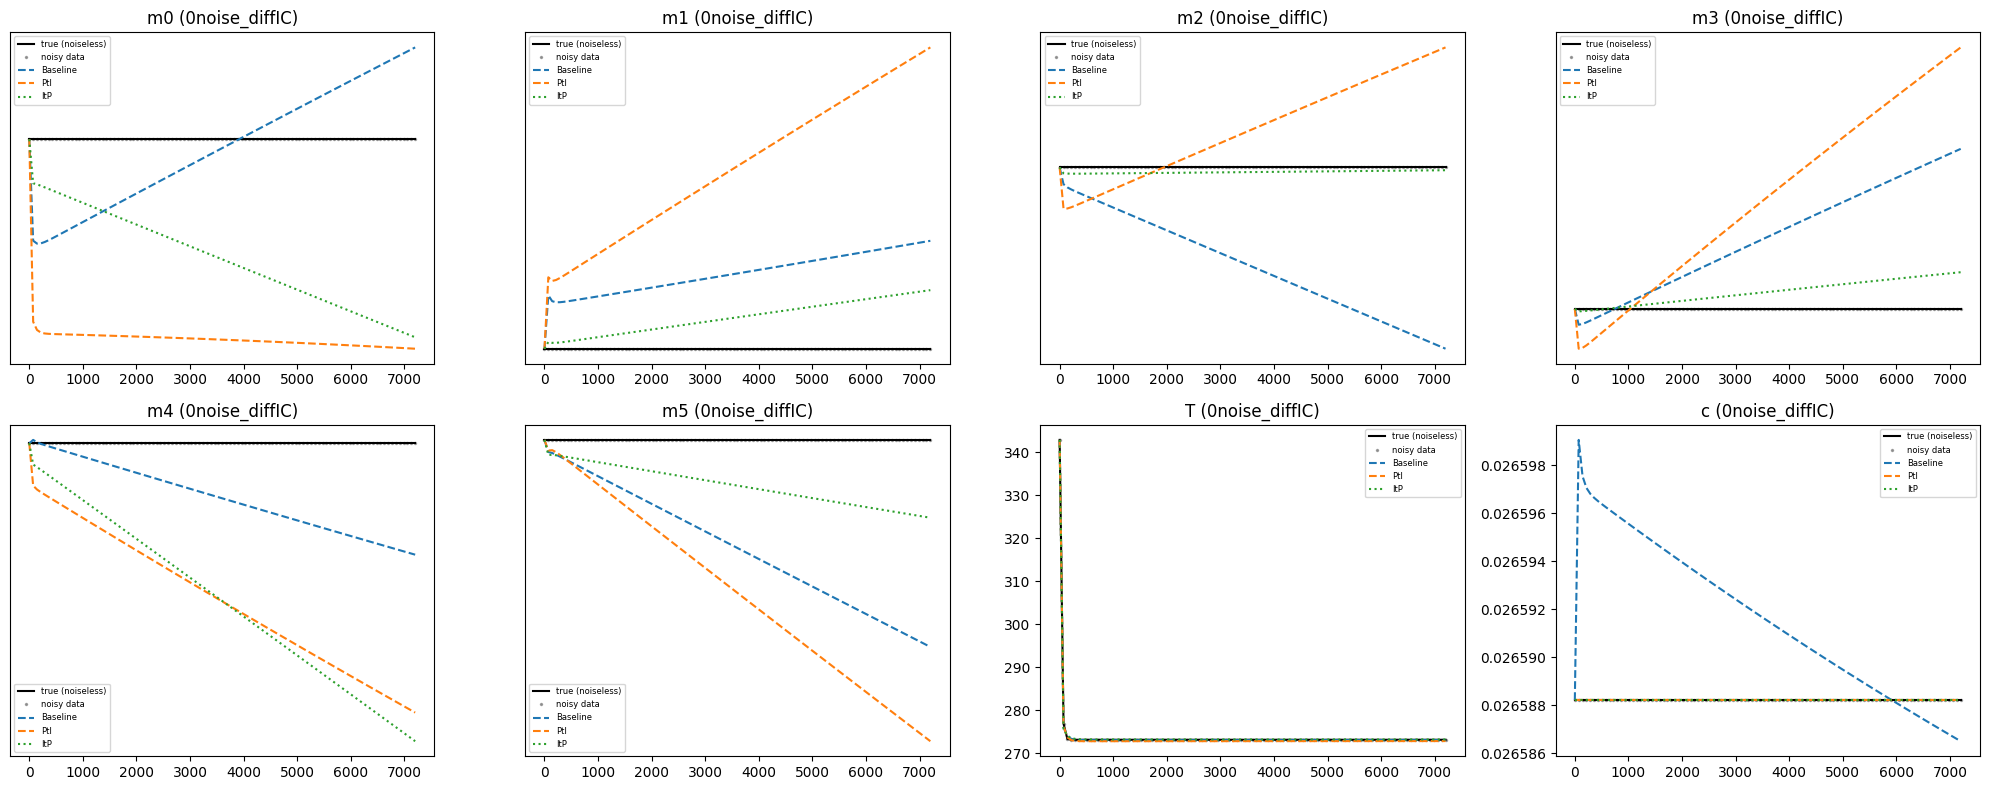


Done. All outputs saved to /content/drive/MyDrive/code/crystal_outputs/
  - model_comparison_12configs_crystal.csv
  - noisy_data_constraint_violation_crystal.csv
  - loss_curves_12models_crystal.png
  - summary_accuracy_violation_crystal.png
  - pareto_accuracy_vs_violation_crystal.png
  - trajectory_<condition>_crystal.png  (x4)


In [5]:


import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import optimistix as optx
from diffrax import (
    diffeqsolve, ODETerm, Kvaerno5, SaveAt, PIDController, RESULTS,
)

import sys
repo_root = "/content/constrained-nodes"
sys.path.insert(0, repo_root)
repo_root = "/content/drive/MyDrive/code"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
from crystallisation import crystallisation

print("JAX backend:", jax.default_backend())

OUT_DIR = "/content/drive/MyDrive/code/crystal_outputs"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# New checkpoint
CKPT_DIR = "/content/drive/MyDrive/code/crystal_ckpts_scaleaware"
Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)

# ================== SYSTEM PARAMETERS (unchanged) ==================
R_GAS = 8.3144
V_REACTOR = 0.5e-3
RHO_S = 789.0
RHO_C = 1332.0
CP_S = 2500.0
KV = 0.866
L0 = 1.0e-6

KAPPA = RHO_C * KV / RHO_S
N_STATE = 8
CONSTR_IDX = jnp.array([0, 3, 7])
CONSTR_COEFFS_FULL = jnp.zeros(N_STATE).at[CONSTR_IDX].set(
    jnp.array([-KAPPA * L0 ** 3, KAPPA, 1.0])
)
labels_all = ["m0", "m1", "m2", "m3", "m4", "m5", "T", "c"]

M0_0, M1_0, M2_0, M3_0, M4_0, M5_0 = 1.0e11, 5.0e4, 3.0e-2, 2.0e-8, 1.5e-14, 1.2e-20
T0 = 315.0
C0 = 0.028
x0 = jnp.array([M0_0, M1_0, M2_0, M3_0, M4_0, M5_0, T0, C0])
Qr = jnp.array([-40.0])

t_end = 3600.0 * 2.0
N_TIME_POINTS = 101
ts = jnp.linspace(0.0, t_end, N_TIME_POINTS)

N_TRAIN, N_VAL, N_TEST = 10, 4, 6
N_TRAJ_TOTAL = N_TRAIN + N_VAL + N_TEST

rhs_true = lambda t, y, args: crystallisation(y, Qr)


@jax.jit
def solve_true(y0):
    sol = diffeqsolve(
        ODETerm(rhs_true), Kvaerno5(root_finder=optx.Newton(rtol=1e-4, atol=1e-4)),
        t0=0.0, t1=t_end, dt0=t_end * 0.001, y0=y0, saveat=SaveAt(ts=ts),
        stepsize_controller=PIDController(rtol=1e-7, atol=1e-9), max_steps=200_000,
    )
    return sol.ys


def generate_dataset(seed, noise_level, ic_spread):
    key_ic = jr.PRNGKey(seed)
    if ic_spread > 0:
        key_ic_moments, key_ic_Tc = jr.split(key_ic)
        scale_factors = 1.0 + ic_spread * jr.normal(key_ic_moments, (N_TRAJ_TOTAL, N_STATE))
        scale_factors = scale_factors.at[:, 6:8].set(
            1.0 + 0.25 * ic_spread * jr.normal(key_ic_Tc, (N_TRAJ_TOTAL, 2))
        )
    else:
        scale_factors = jnp.ones((N_TRAJ_TOTAL, N_STATE))
    x0_batch_all = x0[None, :] * scale_factors
    x0_batch_all = x0_batch_all.at[0].set(x0)
    x0_batch_all = jnp.clip(x0_batch_all, 1e-30, None)

    ys_true_all = jax.vmap(solve_true)(x0_batch_all)
    C_TOTAL_per_traj = jnp.dot(x0_batch_all, CONSTR_COEFFS_FULL)

    key_noise = jr.PRNGKey(seed + 100_000)
    if noise_level > 0:
        noise_factors = 1.0 + noise_level * jr.normal(key_noise, ys_true_all.shape)
        ys_noisy_all = ys_true_all * noise_factors
    else:
        ys_noisy_all = ys_true_all

    idx_train = slice(0, N_TRAIN)
    idx_val = slice(N_TRAIN, N_TRAIN + N_VAL)
    idx_test = slice(N_TRAIN + N_VAL, N_TRAJ_TOTAL)

    x0_train, x0_val, x0_test = (x0_batch_all[idx_train], x0_batch_all[idx_val],
                                  x0_batch_all[idx_test])
    ys_true_train, ys_true_val, ys_true_test = (ys_true_all[idx_train],
                                                 ys_true_all[idx_val],
                                                 ys_true_all[idx_test])
    ys_noisy_train, ys_noisy_val, ys_noisy_test = (ys_noisy_all[idx_train],
                                                    ys_noisy_all[idx_val],
                                                    ys_noisy_all[idx_test])
    C_TOTAL_train = C_TOTAL_per_traj[idx_train]
    C_TOTAL_val = C_TOTAL_per_traj[idx_val]
    C_TOTAL_test = C_TOTAL_per_traj[idx_test]

    # Affine (z-score) normalization
    y_mean = ys_noisy_train.reshape(-1, N_STATE).mean(axis=0)
    y_std = jnp.maximum(ys_noisy_train.reshape(-1, N_STATE).std(axis=0),
                         1e-3 * jnp.abs(y_mean) + 1e-30)

    mean_sq_true_train = jnp.mean(ys_true_train ** 2, axis=(0, 1))
    char_scale = jnp.sqrt(jnp.maximum(mean_sq_true_train, 1e-30))

    def normalize(y):
        return (y - y_mean) / y_std

    def denormalize(z):
        return z * y_std + y_mean

    z0_train, z0_val, z0_test = normalize(x0_train), normalize(x0_val), normalize(x0_test)
    zs_noisy_train = normalize(ys_noisy_train)
    zs_noisy_val = normalize(ys_noisy_val)

    return dict(
        noise_level=noise_level, ic_spread=ic_spread,
        x0_batch_all=x0_batch_all, ys_true_all=ys_true_all, ys_noisy_all=ys_noisy_all,
        z0_train=z0_train, z0_val=z0_val, z0_test=z0_test,
        zs_noisy_train=zs_noisy_train, zs_noisy_val=zs_noisy_val,
        ys_true_train=ys_true_train, ys_true_val=ys_true_val, ys_true_test=ys_true_test,
        ys_noisy_train=ys_noisy_train, ys_noisy_val=ys_noisy_val, ys_noisy_test=ys_noisy_test,
        C_TOTAL_train=C_TOTAL_train, C_TOTAL_val=C_TOTAL_val, C_TOTAL_test=C_TOTAL_test,
        y_mean=y_mean, y_std=y_std, normalize=normalize, denormalize=denormalize,
        char_scale=char_scale,
    )


# ================== MODEL DEFINITIONS ==================
class NeuralODE(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, n_state, width, depth, key, activation=jax.nn.softplus):
        mlp = eqx.nn.MLP(n_state, n_state, width, depth, activation=activation, key=key)
        last = mlp.layers[-1]
        last = eqx.tree_at(lambda l: (l.weight, l.bias), last,
                            (jnp.zeros_like(last.weight), jnp.zeros_like(last.bias)))
        self.mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, last)

    def __call__(self, t, z, args):
        return self.mlp(z)


class ProjectedNeuralODE(eqx.Module):
    mlp: eqx.nn.MLP
    c_norm: jnp.ndarray
    v_weight: jnp.ndarray

    def __init__(self, n_state, width, depth, key, y_std, char_scale, activation=jax.nn.softplus):
        mlp = eqx.nn.MLP(n_state, n_state, width, depth, activation=activation, key=key)
        last = mlp.layers[-1]
        last = eqx.tree_at(lambda l: (l.weight, l.bias), last,
                            (jnp.zeros_like(last.weight), jnp.zeros_like(last.bias)))
        self.mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, last)
        coeffs_sub = CONSTR_COEFFS_FULL[CONSTR_IDX]
        y_std_sub = y_std[CONSTR_IDX]
        self.c_norm = coeffs_sub * y_std_sub

        self.v_weight = char_scale[CONSTR_IDX] / (y_std_sub ** 2 * coeffs_sub)

    def __call__(self, t, z, args):
        raw = self.mlp(z)
        c = jax.lax.stop_gradient(self.c_norm)
        v = jax.lax.stop_gradient(self.v_weight)
        sub = raw[CONSTR_IDX]
        weighted_c = v * c
        lam = jnp.dot(c, sub) / jnp.dot(c, weighted_c)
        raw = raw.at[CONSTR_IDX].add(-lam * weighted_c)
        return raw


# ================== NUMERICALLY ROBUST PREDICTION (stiff solver, unchanged) ==================
def predict(model, ts_, z0):
    sol = diffeqsolve(
        ODETerm(model), Kvaerno5(root_finder=optx.Newton(rtol=1e-4, atol=1e-4)),
        t0=ts_[0], t1=ts_[-1], dt0=(ts_[1] - ts_[0]) * 1e-3, y0=z0, saveat=SaveAt(ts=ts_),
        stepsize_controller=PIDController(rtol=1e-5, atol=1e-7), max_steps=200_000,
        throw=False,
    )
    failed = sol.result != RESULTS.successful
    ys = jnp.where(failed, jnp.full_like(sol.ys, 1e3), sol.ys)
    ys = jnp.nan_to_num(ys, nan=1e3, posinf=1e3, neginf=-1e3)
    return ys


batched_predict = jax.vmap(predict, in_axes=(None, None, 0))


def loss_fn(model, ts_, z0_batch, z_target_batch):
    z_pred = batched_predict(model, ts_, z0_batch)
    return jnp.mean((z_pred - z_target_batch) ** 2)


loss_and_grad = eqx.filter_value_and_grad(loss_fn)


def train_model_early_stopping(model, lr, z0_tr, z_target_tr, z0_va, z_target_va,
                                max_steps=8000, val_every=50, patience=15,
                                verbose=True, model_name=""):
    optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr))
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(model, opt_state):
        loss, grads = loss_and_grad(model, ts, z0_tr, z_target_tr)
        updates, opt_state = optimizer.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss

    train_losses = []
    val_losses, val_steps = [], []
    best_val = float("inf")
    best_model = model
    best_step = 0
    steps_since_improve = 0
    t0 = time.time()
    final_step = 0

    for i in range(1, max_steps + 1):
        model, opt_state, loss = step(model, opt_state)
        train_losses.append(float(loss))
        final_step = i

        if i % val_every == 0 or i == 1:
            v = float(loss_fn(model, ts, z0_va, z_target_va))
            val_losses.append(v)
            val_steps.append(i)

            if v < best_val - 1e-9:
                best_val = v
                best_model = model
                best_step = i
                steps_since_improve = 0
            else:
                steps_since_improve += 1

            if verbose and (i % (val_every * 4) == 0 or i == 1):
                print(f"  [{model_name}] step {i:5d}  train {loss:.4e}  "
                      f"val {v:.4e}  best {best_val:.4e} (@{best_step})")

            if steps_since_improve >= patience:
                if verbose:
                    print(f"  [{model_name}] EARLY STOP at step {i} "
                          f"(best val {best_val:.4e} at step {best_step})")
                break

    train_time = time.time() - t0
    history = dict(train_losses=train_losses, val_losses=val_losses, val_steps=val_steps,
                    best_step=best_step, best_val=best_val, stopped_at=final_step)
    return best_model, history, train_time


def project_state(y_row, target, coeffs_full, weight_sub):

    c_pred = jnp.dot(coeffs_full, y_row)
    c_sub = coeffs_full[CONSTR_IDX]
    weighted_c = weight_sub * c_sub
    lam = (c_pred - target) / jnp.dot(c_sub, weighted_c)
    return y_row.at[CONSTR_IDX].add(-lam * weighted_c)


def project_trajectory(y_traj, target, coeffs_full, weight_sub):
    return jax.vmap(lambda row: project_state(row, target, coeffs_full, weight_sub))(y_traj)


def rel_mse(y_pred, y_true):
    mean_sq_true = jnp.mean(y_true ** 2, axis=(0, 1))
    eps = 1e-8
    per_traj = jnp.mean((y_pred - y_true) ** 2 / (mean_sq_true[None, None, :] + eps),
                         axis=(1, 2))
    return per_traj


def rmse(y_pred, y_true):

    per_traj = jnp.sqrt(jnp.mean((y_pred - y_true) ** 2, axis=(1, 2)))
    return per_traj


def constraint_violation(y_pred, target):
    inv = jnp.einsum('bti,i->bt', y_pred, CONSTR_COEFFS_FULL)
    return jnp.mean(jnp.abs(inv - target[:, None]), axis=1)


CONDITIONS = [
    dict(cond_name="0noise_sameIC", noise_level=0.00, ic_spread=0.00, seed=10),
    dict(cond_name="2noise_sameIC", noise_level=0.02, ic_spread=0.00, seed=20),
    dict(cond_name="2noise_diffIC", noise_level=0.02, ic_spread=0.40, seed=30),
    dict(cond_name="0noise_diffIC", noise_level=0.00, ic_spread=0.40, seed=40),
]

print("Generating datasets for all 4 conditions...")
datasets = {}
noisy_violation = {}
for cond in CONDITIONS:
    cname = cond["cond_name"]
    print(f"  {cname}: noise={cond['noise_level']*100:.0f}%, "
          f"IC spread={cond['ic_spread']*100:.0f}%")
    ds = generate_dataset(cond["seed"], cond["noise_level"], cond["ic_spread"])
    datasets[cname] = ds
    noisy_violation[cname] = constraint_violation(ds["ys_noisy_test"], ds["C_TOTAL_test"])


# ================== ARCHITECTURE (unchanged from the stiff-solver fix) ==================
BEST_WIDTH = 256
BEST_DEPTH = 4
BEST_LR = 1e-4

print(f"Architecture to be used for the 12 models: width={BEST_WIDTH}, depth={BEST_DEPTH}, lr={BEST_LR:.2e}")


def make_model(method, seed_key, ds):
    if method == "PtI":
        return ProjectedNeuralODE(N_STATE, BEST_WIDTH, BEST_DEPTH, seed_key,
                                   ds["y_std"], ds["char_scale"])
    return NeuralODE(N_STATE, BEST_WIDTH, BEST_DEPTH, seed_key)  # Baseline / ItP


def ckpt_path(cname, method):
    return f"{CKPT_DIR}/{cname}__{method}"


def save_checkpoint(cname, method, model, history, train_time, y_pred_test):
    path = ckpt_path(cname, method)
    eqx.tree_serialise_leaves(path + ".eqx", model)
    with open(path + ".pkl", "wb") as f:
        pickle.dump({
            "history": history, "train_time": train_time,
            "y_pred_test": np.array(y_pred_test),
        }, f)


def load_checkpoint(cname, method, model_template):
    path = ckpt_path(cname, method)
    if not (Path(path + ".eqx").exists() and Path(path + ".pkl").exists()):
        return None
    model = eqx.tree_deserialise_leaves(path + ".eqx", model_template)
    with open(path + ".pkl", "rb") as f:
        meta = pickle.load(f)
    return model, meta["history"], meta["train_time"], jnp.array(meta["y_pred_test"])


MAX_STEPS_FINAL = 6000
VAL_EVERY = 50
PATIENCE = 15
METHODS = ["Baseline", "PtI", "ItP"]

all_models, all_histories, all_preds = {}, {}, {}
results_rows = []
model_key_counter = 0

for cond in CONDITIONS:
    cname = cond["cond_name"]
    ds = datasets[cname]
    print(f"\n{'='*70}\nCONDITION: {cname}\n{'='*70}")

    for method in METHODS:
        model_key_counter += 1
        seed_key = jr.PRNGKey(1000 + model_key_counter)
        name = f"{cname} / {method}"
        model_template = make_model(method, seed_key, ds)

        cached = load_checkpoint(cname, method, model_template)
        if cached is not None:
            print(f"  [{name}] Checkpoint found; skipping.")
            trained_model, history, train_time, y_pred_test = cached
        else:
            print(f"\n--- Training: {name} ---")
            trained_model, history, train_time = train_model_early_stopping(
                model_template, BEST_LR, ds["z0_train"], ds["zs_noisy_train"],
                ds["z0_val"], ds["zs_noisy_val"],
                max_steps=MAX_STEPS_FINAL, val_every=VAL_EVERY, patience=PATIENCE,
                verbose=True, model_name=name,
            )
            z_pred_test = batched_predict(trained_model, ts, ds["z0_test"])
            y_pred_test = ds["denormalize"](z_pred_test)
            if method == "ItP":
                weight_sub = ds["char_scale"][CONSTR_IDX] / CONSTR_COEFFS_FULL[CONSTR_IDX]
                y_pred_test = jax.vmap(
                    lambda y_traj, target: project_trajectory(
                        y_traj, target, CONSTR_COEFFS_FULL, weight_sub)
                )(y_pred_test, ds["C_TOTAL_test"])
            save_checkpoint(cname, method, trained_model, history, train_time, y_pred_test)
            print(f"  -> checkpoint saved: {ckpt_path(cname, method)}")

        all_models[(cname, method)] = trained_model
        all_histories[(cname, method)] = history
        all_preds[(cname, method)] = y_pred_test

        rel_mse_vals = rel_mse(y_pred_test, ds["ys_true_test"])
        rmse_vals = rmse(y_pred_test, ds["ys_true_test"])
        viol_vals = constraint_violation(y_pred_test, ds["C_TOTAL_test"])
        results_rows.append({
            "condition": cname, "method": method,
            "noise_level": cond["noise_level"], "ic_spread": cond["ic_spread"],
            "rel_mse_mean": float(jnp.mean(rel_mse_vals)), "rel_mse_std": float(jnp.std(rel_mse_vals)),
            "rmse_mean": float(jnp.mean(rmse_vals)), "rmse_std": float(jnp.std(rmse_vals)),
            "violation_mean": float(jnp.mean(viol_vals)), "violation_std": float(jnp.std(viol_vals)),
            "best_step": history["best_step"], "stopped_at": history["stopped_at"],
            "train_time_s": train_time,
        })

results_df = pd.DataFrame(results_rows)
results_df.to_csv(f"{OUT_DIR}/model_comparison_12configs_crystal.csv", index=False)
print(results_df.to_string(index=False))

noisy_violation_rows = [
    {"condition": c, "violation_mean": float(jnp.mean(noisy_violation[c])),
     "violation_std": float(jnp.std(noisy_violation[c]))}
    for c in noisy_violation
]
pd.DataFrame(noisy_violation_rows).to_csv(
    f"{OUT_DIR}/noisy_data_constraint_violation_crystal.csv", index=False)

# ================== TRAIN/VAL LOSS CURVES (overfitting check) -- 4x3 grid ==================
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
for row, cond in enumerate(CONDITIONS):
    cname = cond["cond_name"]
    for col, method in enumerate(METHODS):
        ax = axes[row, col]
        h = all_histories[(cname, method)]
        ax.plot(range(1, len(h["train_losses"]) + 1), h["train_losses"],
                label="train_loss", alpha=0.7, linewidth=1)
        ax.plot(h["val_steps"], h["val_losses"], "o-", label="val_loss",
                markersize=3, linewidth=1.5)
        ax.axvline(h["best_step"], color="red", linestyle="--", linewidth=1,
                    label=f"best (step {h['best_step']})")
        ax.set(yscale="log", title=f"{cname} / {method}", xlabel="step", ylabel="loss")
        ax.legend(fontsize=6)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/loss_curves_12models_crystal.png", dpi=150)
plt.show()

# ================== SUMMARY DOT-AND-WHISKER PLOT (mean +/- std) ==================
# Same style as Cases 1-2, replacing the violin plots.
METHOD_COLORS = {"Baseline": "#888888", "PtI": "#1f77b4", "ItP": "#2ca02c"}
cond_names = [c["cond_name"] for c in CONDITIONS]
x = np.arange(len(cond_names))
offsets = {"Baseline": -0.15, "PtI": 0.0, "ItP": 0.15}

fig_s, axes_s = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

for method in METHODS:
    means = [results_df[(results_df.condition == c) & (results_df.method == method)]
             ["rel_mse_mean"].values[0] for c in cond_names]
    stds = [results_df[(results_df.condition == c) & (results_df.method == method)]
            ["rel_mse_std"].values[0] for c in cond_names]
    axes_s[0].errorbar(x + offsets[method], means, yerr=stds, fmt="o", markersize=7,
                        capsize=4, color=METHOD_COLORS[method], label=method)
axes_s[0].set(ylabel="Relative MSE", yscale="log", title="Prediction accuracy")
axes_s[0].legend()

for method in METHODS:
    means = [results_df[(results_df.condition == c) & (results_df.method == method)]
             ["violation_mean"].values[0] for c in cond_names]
    stds = [results_df[(results_df.condition == c) & (results_df.method == method)]
            ["violation_std"].values[0] for c in cond_names]
    axes_s[1].errorbar(x + offsets[method], means, yerr=stds, fmt="o", markersize=7,
                        capsize=4, color=METHOD_COLORS[method], label=method)

noisy_means = [float(jnp.mean(noisy_violation[c])) for c in cond_names]
noisy_stds = [float(jnp.std(noisy_violation[c])) for c in cond_names]
axes_s[1].errorbar(x, noisy_means, yerr=noisy_stds, fmt="k*", markersize=12,
                    capsize=4, label="Noisy data (reference)")

axes_s[1].set(ylabel="Mean |constraint violation|", yscale="log", title="Constraint violation")
axes_s[1].set_xticks(x)
axes_s[1].set_xticklabels(cond_names, rotation=15)
axes_s[1].legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/summary_accuracy_violation_crystal.png", dpi=200)
plt.show()

# ================== PARETO / TRADE-OFF PLOT ==================
fig_p, axes_p = plt.subplots(2, 2, figsize=(11, 9))

for ax, cond in zip(axes_p.flat, CONDITIONS):
    cname = cond["cond_name"]
    for method in METHODS:
        row = results_df[(results_df.condition == cname) & (results_df.method == method)].iloc[0]
        ax.errorbar(
            row["violation_mean"], row["rel_mse_mean"], yerr=row["rel_mse_std"],
            fmt="o", markersize=9, capsize=4, color=METHOD_COLORS[method], label=method,
        )
        ax.annotate(method, (row["violation_mean"], row["rel_mse_mean"]),
                    textcoords="offset points", xytext=(6, 6), fontsize=8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Mean constraint violation")
    ax.set_ylabel("Mean relative MSE")
    ax.set_title(cname)

fig_p.suptitle("Accuracy vs. constraint-violation trade-off")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/pareto_accuracy_vs_violation_crystal.png", dpi=200)
plt.show()

# ================== EXAMPLE TRAJECTORY PLOTS (one per condition) ==================
LOG_STATES = {"m0", "m1", "m2", "m3", "m4", "m5"}
for cond in CONDITIONS:
    cname = cond["cond_name"]
    ds = datasets[cname]
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    axes = axes.ravel()
    for idx, varname in enumerate(labels_all):
        ax = axes[idx]
        ax.plot(ts, ds["ys_true_test"][0, :, idx], "k-", label="true (noiseless)")
        ax.plot(ts, ds["ys_noisy_test"][0, :, idx], "k.", alpha=0.3, markersize=3,
                label="noisy data")
        for method, style in zip(METHODS, ["--", "--", ":"]):
            ax.plot(ts, all_preds[(cname, method)][0, :, idx], style, label=method)
        if varname in LOG_STATES:
            ax.set_yscale("symlog", linthresh=1e-20)
        ax.legend(fontsize=6)
        ax.set(title=f"{varname} ({cname})")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/trajectory_{cname}_crystal.png", dpi=150)
    plt.show()

print(f"\nDone. All outputs saved to {OUT_DIR}/")
print("  - model_comparison_12configs_crystal.csv")
print("  - noisy_data_constraint_violation_crystal.csv")
print("  - loss_curves_12models_crystal.png")
print("  - summary_accuracy_violation_crystal.png")
print("  - pareto_accuracy_vs_violation_crystal.png")
print("  - trajectory_<condition>_crystal.png  (x4)")